In [14]:
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf

In [15]:
# Synthetic Data
num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(mean=[0, 3], cov=[[1, 0.55], [0.55, 1]], size=num_samples_per_class)
positive_samples = np.random.multivariate_normal(mean=[3, 0], cov=[[1, 0.55], [0.55, 1]], size=num_samples_per_class)
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"), np.ones((num_samples_per_class, 1), dtype="float32")))

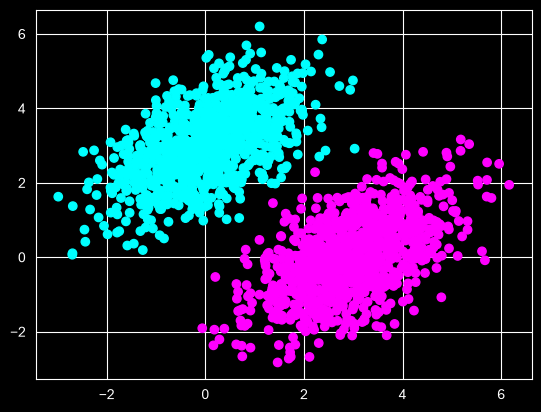

In [16]:
plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0], cmap="cool")
plt.show()

In [17]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))
W

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
array([[0.74667096],
       [0.9200487 ]], dtype=float32)>

In [18]:
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b


In [19]:
def mean_squared_error(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

In [20]:
learning_rate = 0.1
def training_step(inputs, targets, W, b):
    with tf.GradientTape() as tape:
        predictions = model(inputs, W, b)
        loss = mean_squared_error(predictions, targets)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

In [21]:
epoches = 50
for epoch in range(epoches):
    loss = training_step(inputs, targets, W, b)
    if epoch%10 ==0:
        print(f"Loss at step {epoch}: {loss:.4f}")


Loss at step 0: 6.7289
Loss at step 10: 0.0907
Loss at step 20: 0.0497
Loss at step 30: 0.0335
Loss at step 40: 0.0272


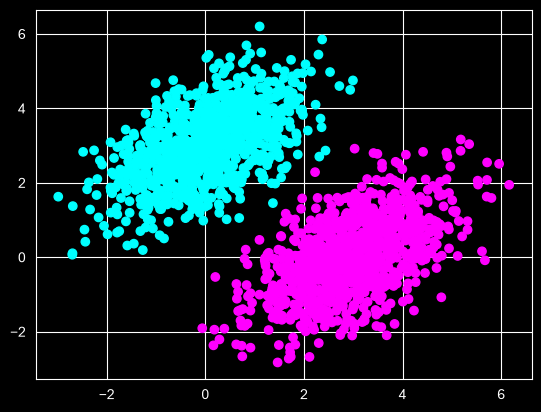

In [22]:
predictions = model(inputs, W, b)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5, cmap="cool")
plt.show()



In [23]:
W

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
array([[ 0.1758578 ],
       [-0.13127428]], dtype=float32)>

In [24]:
b

<tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([0.41712874], dtype=float32)>

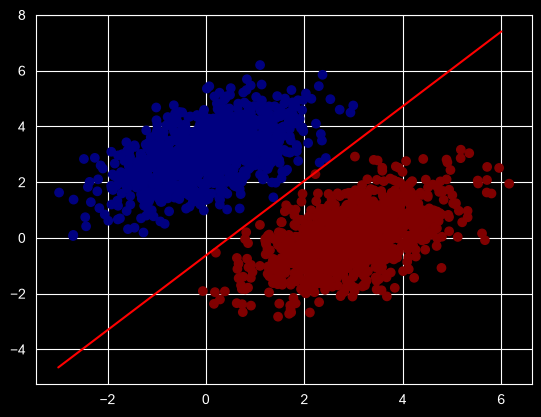

In [25]:
x = np.linspace(-3, 6, 100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5, cmap="jet")

In [26]:
predictions = model(inputs, W, b)
predicted_labels = predictions[:, 0] > 0.5
predicted_labels

<tf.Tensor: shape=(2000,), dtype=bool, numpy=array([False, False, False, ...,  True,  True,  True], shape=(2000,))>

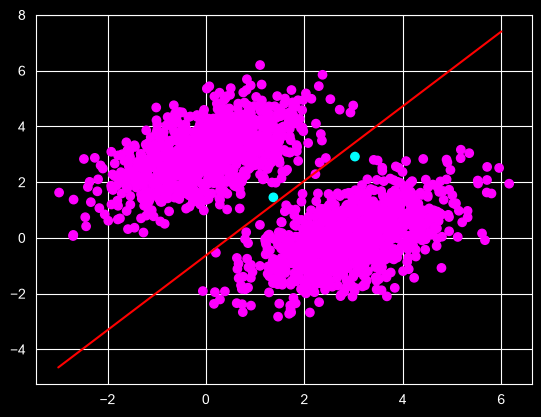

In [27]:
x = np.linspace(-3, 6, 100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
matches = (predicted_labels == targets.flatten())
plt.scatter(inputs[:, 0], inputs[:, 1], c=matches, cmap="cool")

In [28]:
import numpy as np
matches = (predicted_labels == targets.flatten())
accuracy = np.mean(matches)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 99.90%
